# Importing

In [1]:
import os
import sys
import inspect
currentdir = os.getcwd()
parentdir = os.path.dirname(currentdir)

#------------ FILES PARENTDIR ------------#
sys.path.insert(0, parentdir)
from NFW_class import NFW_profile, r1
from Isothermal_paper_2206 import stitchSIDMcore, deltaSqare, findTwoDeltaMinimum
# helpfull functions and constans
import Config as cfg

#------------ FILES CURRENTDIR ------------#
sys.path.insert(0, currentdir)
from plotCircularVelocity import plotCircularVelocity
from plotDensity import plotDensity
from plotVelocityDisparsion import plotVelocityDisparsion
from plotContour import plotContourBasic
from plotsWholeComparison import plotFullComparison, plotFullComparison_vol2



# Sets of simulation

In [2]:
# Evolution of galaxy
time_evolution = 550 #[Gyr]
time_evolution_SI = time_evolution * cfg.Gyr #[s]

# anihilation cross-section
sigma_m = 1 #[cm^2/g]
sigma_m_SI = sigma_m * 10**(-4) * 10**3 # [m^2/kg]

# Virial mass
M_vir = 10**11 # [M_sun]

# concentration of DM
const_c = 15 # dimesionless

sim_parms = [M_vir, const_c, sigma_m, time_evolution]

# Creating NFW Class

In [3]:
NFW_profile = NFW_profile(M_vir, const_c)

In [4]:
r_s = NFW_profile.r_s
rounded_r_s = cfg.rounded_number(r_s, 3)

rho_s = NFW_profile.rho_s
rounded_rho_s = cfg.rounded_number(rho_s, 3)
print(f"rho_s = {rounded_rho_s} [M_solar / kpc^3], r_s = {rounded_r_s} [kpc]")

#-------------------------------------------------------------------------------------------
# new way to get r1
r_1 = r1(NFW_profile,sigmamx=cfg.sigma_m,tage=(cfg.time_evolution/cfg.Gyr))
print(f"r_1 = {r_1} [kpc]")

rho_s = 17200000.0 [M_solar / kpc^3], r_s = 6.32 [kpc]
r_1 = 4.90267137751015 [kpc]


# Isothermal

In [5]:
SIDM_stitchSIDMcore = stitchSIDMcore(r_1, NFW_profile)

# Isotherma: low dense
SIDM_LoDens = findTwoDeltaMinimum(r_1, NFW_profile)[0]
# Isothermal: high dense
SIDM_HiDens = findTwoDeltaMinimum(r_1, NFW_profile)[1]

In [6]:
# rhodm0 -> central DM density. Isothermal density
print(f"SIDM_stitchSIDMcore, rhodm0:  {'{:.2E}'.format(SIDM_stitchSIDMcore[0])} [M_sun / kpc^3]. ")
print(f"SIDM_LoDens, rhodm0:  {'{:.2E}'.format(SIDM_LoDens[0])} [M_sun / kpc^3]. ")
print(f"SIDM_HiDens, rhodm0:  {'{:.2E}'.format(SIDM_HiDens[0])} [M_sun / kpc^3]. ")

# sigma0 -> central DM velocity dispersion. Isothermal velocity dispersion (nu, sigma)
change_units = cfg.kpc_SI / cfg.Gyr * 10**(-3)
print(f"SIDM_stitchSIDMcore, sigma0: {'{:.1f}'.format(SIDM_stitchSIDMcore[1] * change_units)} [km/s]")
print(f"SIDM_LoDens, sigma0: {'{:.1f}'.format(SIDM_LoDens[1] * change_units)} [km/s]")
print(f"SIDM_HiDens, sigma0: {'{:.1f}'.format(SIDM_HiDens[1] * change_units)} [km/s]")

SIDM_stitchSIDMcore, rhodm0:  5.84E+07 [M_sun / kpc^3]. 
SIDM_LoDens, rhodm0:  5.84E+07 [M_sun / kpc^3]. 
SIDM_HiDens, rhodm0:  1.72E+11 [M_sun / kpc^3]. 
SIDM_stitchSIDMcore, sigma0: 53.3 [km/s]
SIDM_LoDens, sigma0: 53.3 [km/s]
SIDM_HiDens, sigma0: 61.1 [km/s]


# Density profiles

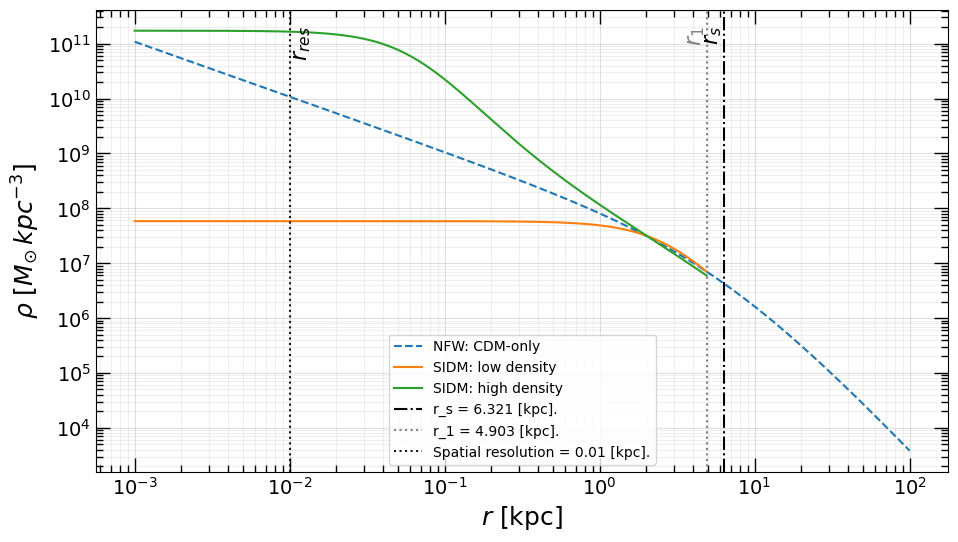

In [7]:
plotDensity(NFW_profile, SIDM_LoDens, SIDM_HiDens, r_1)

# Circular velocity

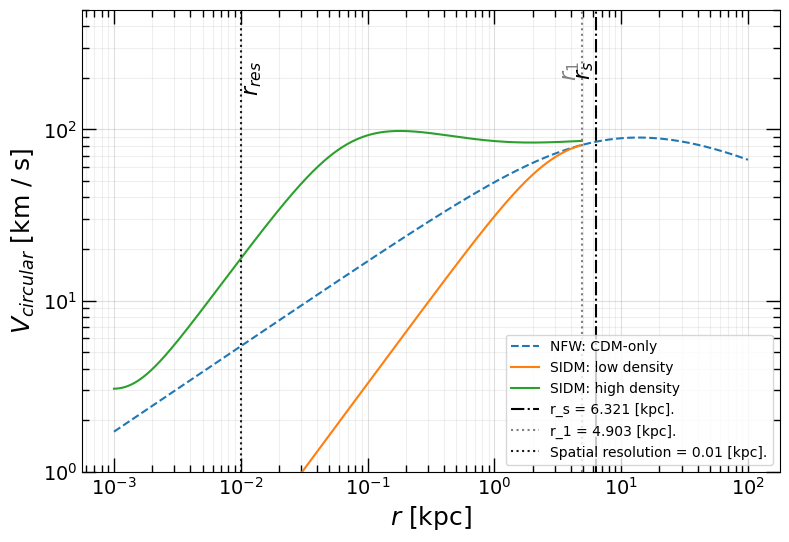

In [8]:
plotCircularVelocity(NFW_profile, SIDM_LoDens, SIDM_HiDens, r_1)

# Dispersion velocity

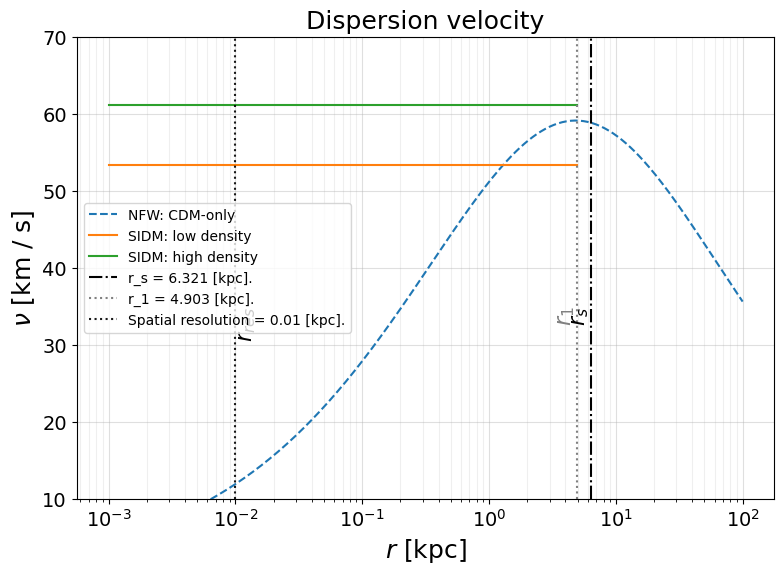

SIDM-low density, dispersion velocity: 53.3 [km/s]
SIDM-high density, dispersion velocity: 61.1 [km/s]


In [9]:
plotVelocityDisparsion(NFW_profile, SIDM_LoDens, SIDM_HiDens, r_1)

print(f"SIDM-low density, dispersion velocity: {'{:.1f}'.format(SIDM_LoDens[1] * change_units)} [km/s]")
print(f"SIDM-high density, dispersion velocity: {'{:.1f}'.format(SIDM_HiDens[1] * change_units)} [km/s]")

# Contour plot

CDM-olny, rho value at r1: 7.02E+06 [M_sun / kpc^3] --> rho(r_1) 
CDM-olny, rho value at spatial resolution (0.01 kpc): 1.08E+10 [M_sun / kpc^3]. --> rho(r_res)
Velocity dispersion (nu) at r1: 59.1 [km/s] --> v(r_1)


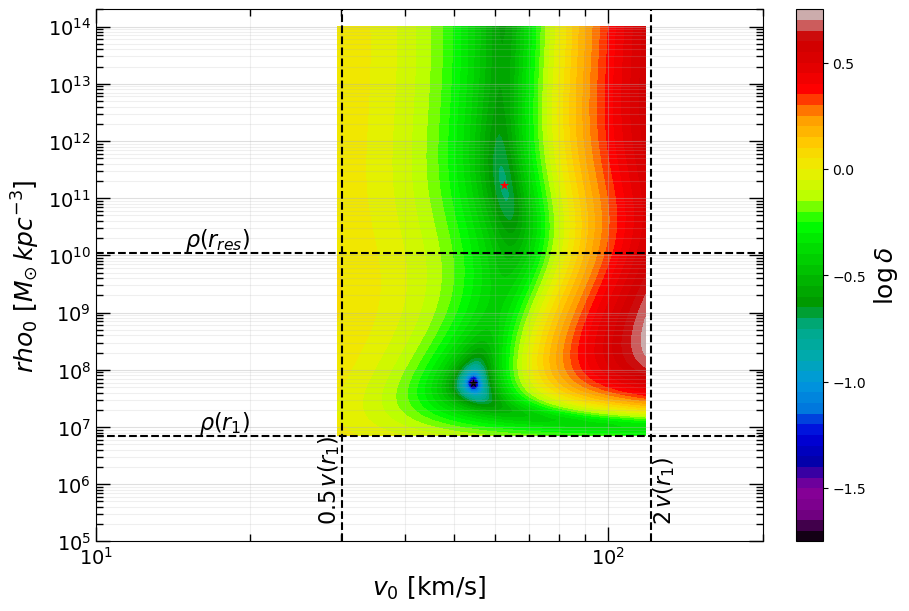

In [10]:
plotContourBasic(NFW_profile, SIDM_LoDens, SIDM_HiDens, r_1)

# Save all plots

In [11]:
# plotFullComparison(NFW_profile, SIDM_LoDens, SIDM_HiDens, r_1, sim_parms)

In [13]:
# plotFullComparison_vol2(NFW_profile, SIDM_LoDens, SIDM_HiDens, r_1, sim_parms)